In [63]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.data_processing.dataset_loader import CoastData

In [2]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2

In [36]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../data/SCLabels_v1.0.0/"))

# Load the data, all the different stations
data = CoastData(data_path)

station_names = data.get_station_names()
print("Stations available: ", station_names)

CoastData: global - 1717 images
Stations available:  ['agrelo', 'arenaldentem', 'cadiz', 'cies', 'samarador']


In [39]:
k = 5
data_splits = data.get_kfold_splits(k, test_size=0.1)
print(data_splits.keys())

Coast: agrelo, Total size: 244
Coast: arenaldentem, Total size: 40
Coast: cadiz, Total size: 946
Coast: cies, Total size: 430
Coast: samarador, Total size: 57
dict_keys(['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4'])


In [40]:

for fold in data_splits.keys():
    total = (len(data_splits[fold]['train']['images']) +
             len(data_splits[fold]['validation']['images']) +
             len(data_splits[fold]['test']['images']))
    print(f"Total images in fold {fold}: {total}")
    print(f"Fold: {fold}")
    print("Fold train size: ", len(data_splits[fold]['train']['images']))
    print("Fold validation size: ", len(data_splits[fold]['validation']['images']))
    print("Fold test size: ", len(data_splits[fold]['test']['images']))
    print("")

Total images in fold fold_0: 1717
Fold: fold_0
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_1: 1717
Fold: fold_1
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_2: 1717
Fold: fold_2
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_3: 1717
Fold: fold_3
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_4: 1717
Fold: fold_4
Fold train size:  1228
Fold validation size:  316
Fold test size:  173



In [29]:
import pandas as pd
import os

file_roles = {}

for fold_name in data_splits.keys():
    for split_type in ['validation', 'train', 'test']:
        if data_splits[fold_name][split_type].get('images'):

            file_paths = data_splits[fold_name][split_type]['images']

            for file_path in file_paths:
                filename = os.path.basename(file_path)

                if filename not in file_roles:
                    file_roles[filename] = {}
                
                file_roles[filename][fold_name] = split_type

df = pd.DataFrame.from_dict(file_roles, orient='index')

df = df.reindex(columns=sorted(data_splits.keys()))
df = df.reset_index().rename(columns={'index': 'filename'})

output_filename = 'folds_summary.csv'
df.to_csv(output_filename, index=False)

print(df.head())

                                            filename      fold_0 fold_1  \
0  1555342200.Mon.Apr.15_16_30_00.CET.2019.agrelo...  validation  train   
1  1575910440.Mon.Dec.09_17_54_00.CET.2019.agrelo...  validation  train   
2  1549465320.Wed.Feb.06_16_02_00.CET.2019.agrelo...  validation  train   
3  1568737306.Tue.Sep.17_17_21_46.CET.2019.agrelo...  validation  train   
4  1572880800.Mon.Nov.04_16_20_00.CET.2019.agrelo...  validation  train   

  fold_2 fold_3 fold_4  
0  train  train  train  
1  train  train  train  
2  train  train  train  
3  train  train  train  
4  train  train  train  


  agrelo: Train=176, Val=43, Test=25
  arenaldentem: Train=29, Val=7, Test=4
  cadiz: Train=681, Val=170, Test=95
  cies: Train=310, Val=77, Test=43
  samarador: Train=41, Val=10, Test=6

  agrelo: Train=176, Val=43, Test=25
  arenaldentem: Train=29, Val=7, Test=4
  cadiz: Train=681, Val=170, Test=95
  cies: Train=310, Val=77, Test=43
  samarador: Train=41, Val=10, Test=6

  agrelo: Train=176, Val=43, Test=25
  arenaldentem: Train=29, Val=7, Test=4
  cadiz: Train=681, Val=170, Test=95
  cies: Train=310, Val=77, Test=43
  samarador: Train=41, Val=10, Test=6

  agrelo: Train=176, Val=43, Test=25
  arenaldentem: Train=29, Val=7, Test=4
  cadiz: Train=681, Val=170, Test=95
  cies: Train=310, Val=77, Test=43
  samarador: Train=41, Val=10, Test=6

  agrelo: Train=172, Val=47, Test=25
  arenaldentem: Train=28, Val=8, Test=4
  cadiz: Train=680, Val=171, Test=95
  cies: Train=308, Val=79, Test=43
  samarador: Train=40, Val=11, Test=6



C:\Users\josep\AppData\Local\Temp\ipykernel_25456\3844479685.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


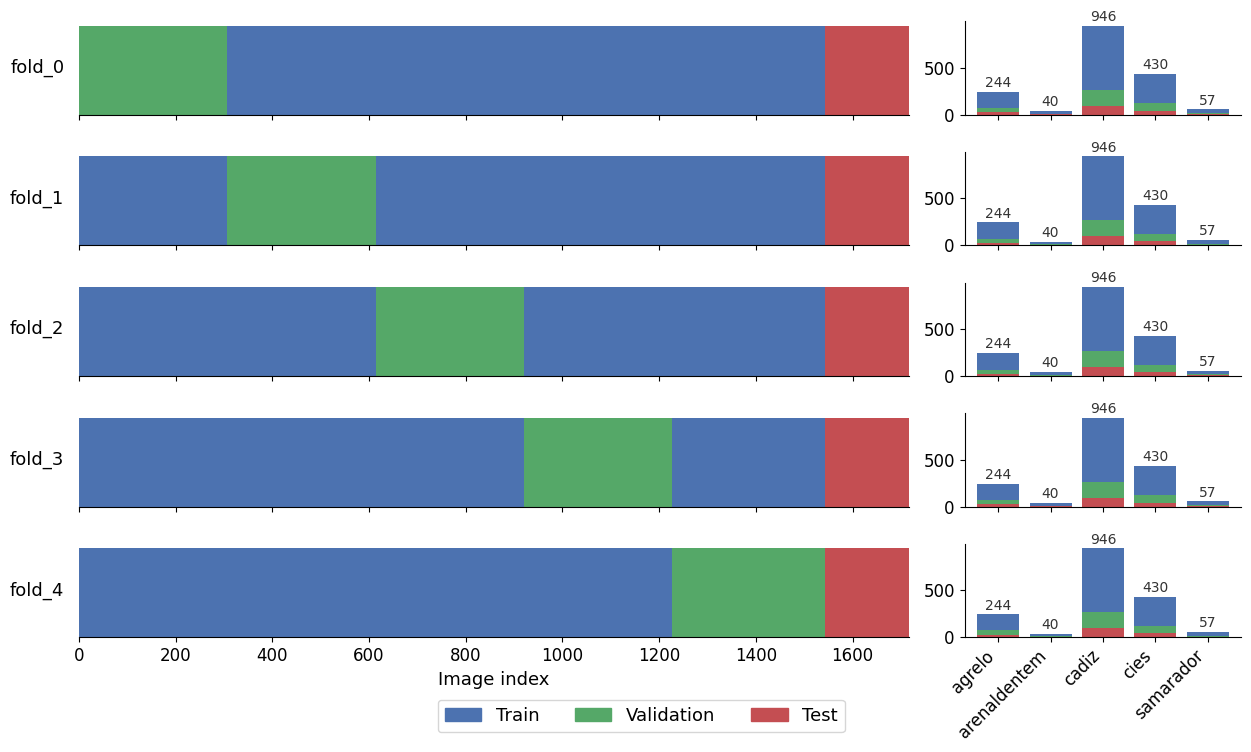

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# --- Load CSV ---
csv_path = 'folds_summary.csv'
df = pd.read_csv(csv_path)

# --- Settings ---
color_map = {'train': '#4C72B0', 'validation': '#55A868', 'test': '#C44E52'}
fold_cols = [col for col in df.columns if col.startswith('fold_')]
n_folds = len(fold_cols)

# --- Figure layout ---
fig = plt.figure(figsize=(15, n_folds * 1.6))
gs = gridspec.GridSpec(n_folds, 2, figure=fig,
                       width_ratios=[3, 1], wspace=0.1,
                       height_ratios=[1]*n_folds, hspace=0.4)

axs_split, axs_count = [], []

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# --- Iterate folds ---
for i, fold in enumerate(fold_cols):
    ax_split = fig.add_subplot(gs[i, 0])
    ax_count = fig.add_subplot(gs[i, 1])
    axs_split.append(ax_split)
    axs_count.append(ax_count)

    # --- Left plot: bar per image (visualize split) ---
    split_values = df[fold]
    colors = split_values.map(color_map)
    x_axis = range(len(split_values))
    y_axis = [1] * len(split_values)
    ax_split.bar(x_axis, y_axis, color=colors, width=1.0)
    ax_split.set_xlim([0, len(split_values)])
    ax_split.set_yticks([])
    ax_split.spines[['top', 'right', 'left']].set_visible(False)
    ax_split.set_ylabel(f'{fold}', rotation=0, labelpad=30, fontsize=13, va='center')

    # Hide x labels except for last
    if i < n_folds - 1:
        ax_split.tick_params(axis='x', labelbottom=False)
    else:
        ax_split.set_xlabel('Image index')

    # --- Right plot: counts ---
    counts = split_values.value_counts().reindex(['train', 'validation', 'test']).fillna(0)

    # --- Count per station and split ---
    train_counts, val_counts, test_counts = [], [], []
    for station in station_names:
        mask_station = df['filename'].str.contains(station)
        split_station = split_values[mask_station]

        train_counts.append((split_station == 'train').sum())
        val_counts.append((split_station == 'validation').sum())
        test_counts.append((split_station == 'test').sum())

        print(f"  {station}: Train={train_counts[-1]}, Val={val_counts[-1]}, Test={test_counts[-1]}")
    print()
    x = np.arange(len(station_names))

    # --- Stacked bars ---
    ax_count.bar(x, test_counts, label='Test', color=color_map['test'])
    ax_count.bar(x, val_counts, bottom=test_counts, label='Validation', color=color_map['validation'])
    ax_count.bar(x, train_counts, bottom=np.array(test_counts) + np.array(val_counts), label='Train', color=color_map['train'])

    for j, (t, v, s) in enumerate(zip(train_counts, val_counts, test_counts)):
        total = t + v + s
        ax_count.text(j, total + max(np.array(train_counts) + np.array(val_counts) + np.array(test_counts)) * 0.02,
                      str(total), ha='center', va='bottom', fontsize=10, color='#333333')

    ax_count.set_xticks(x)
    if i == n_folds - 1:
        ax_count.set_xticklabels(station_names, rotation=45, ha='right')
    else:
        ax_count.set_xticklabels([])
    ax_count.spines[['top', 'right']].set_visible(False)

# --- Add global legend ---
patches = [mpatches.Patch(color=color_map[c], label=c.capitalize())
           for c in color_map.keys()]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), prop={'size':13})

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()
